In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Jupyter plotting backend
%matplotlib inline

df = pd.read_csv('/Users/pitzsb1/Documents/HBAC/train.csv')


print(df.shape)
print(df['expert_consensus'].value_counts()) # 클래스 분포 확인
print(df.head())

(106800, 15)
expert_consensus
Seizure    20933
GRDA       18861
Other      18808
GPD        16702
LRDA       16640
LPD        14856
Name: count, dtype: int64
       eeg_id  eeg_sub_id  eeg_label_offset_seconds  spectrogram_id  \
0  1628180742           0                       0.0          353733   
1  1628180742           1                       6.0          353733   
2  1628180742           2                       8.0          353733   
3  1628180742           3                      18.0          353733   
4  1628180742           4                      24.0          353733   

   spectrogram_sub_id  spectrogram_label_offset_seconds    label_id  \
0                   0                               0.0   127492639   
1                   1                               6.0  3887563113   
2                   2                               8.0  1142670488   
3                   3                              18.0  2718991173   
4                   4                              24.0  308

(18000, 20)
['Fp1', 'F3', 'C3', 'P3', 'F7', 'T3', 'T5', 'O1', 'Fz', 'Cz', 'Pz', 'Fp2', 'F4', 'C4', 'P4', 'F8', 'T4', 'T6', 'O2', 'EKG']


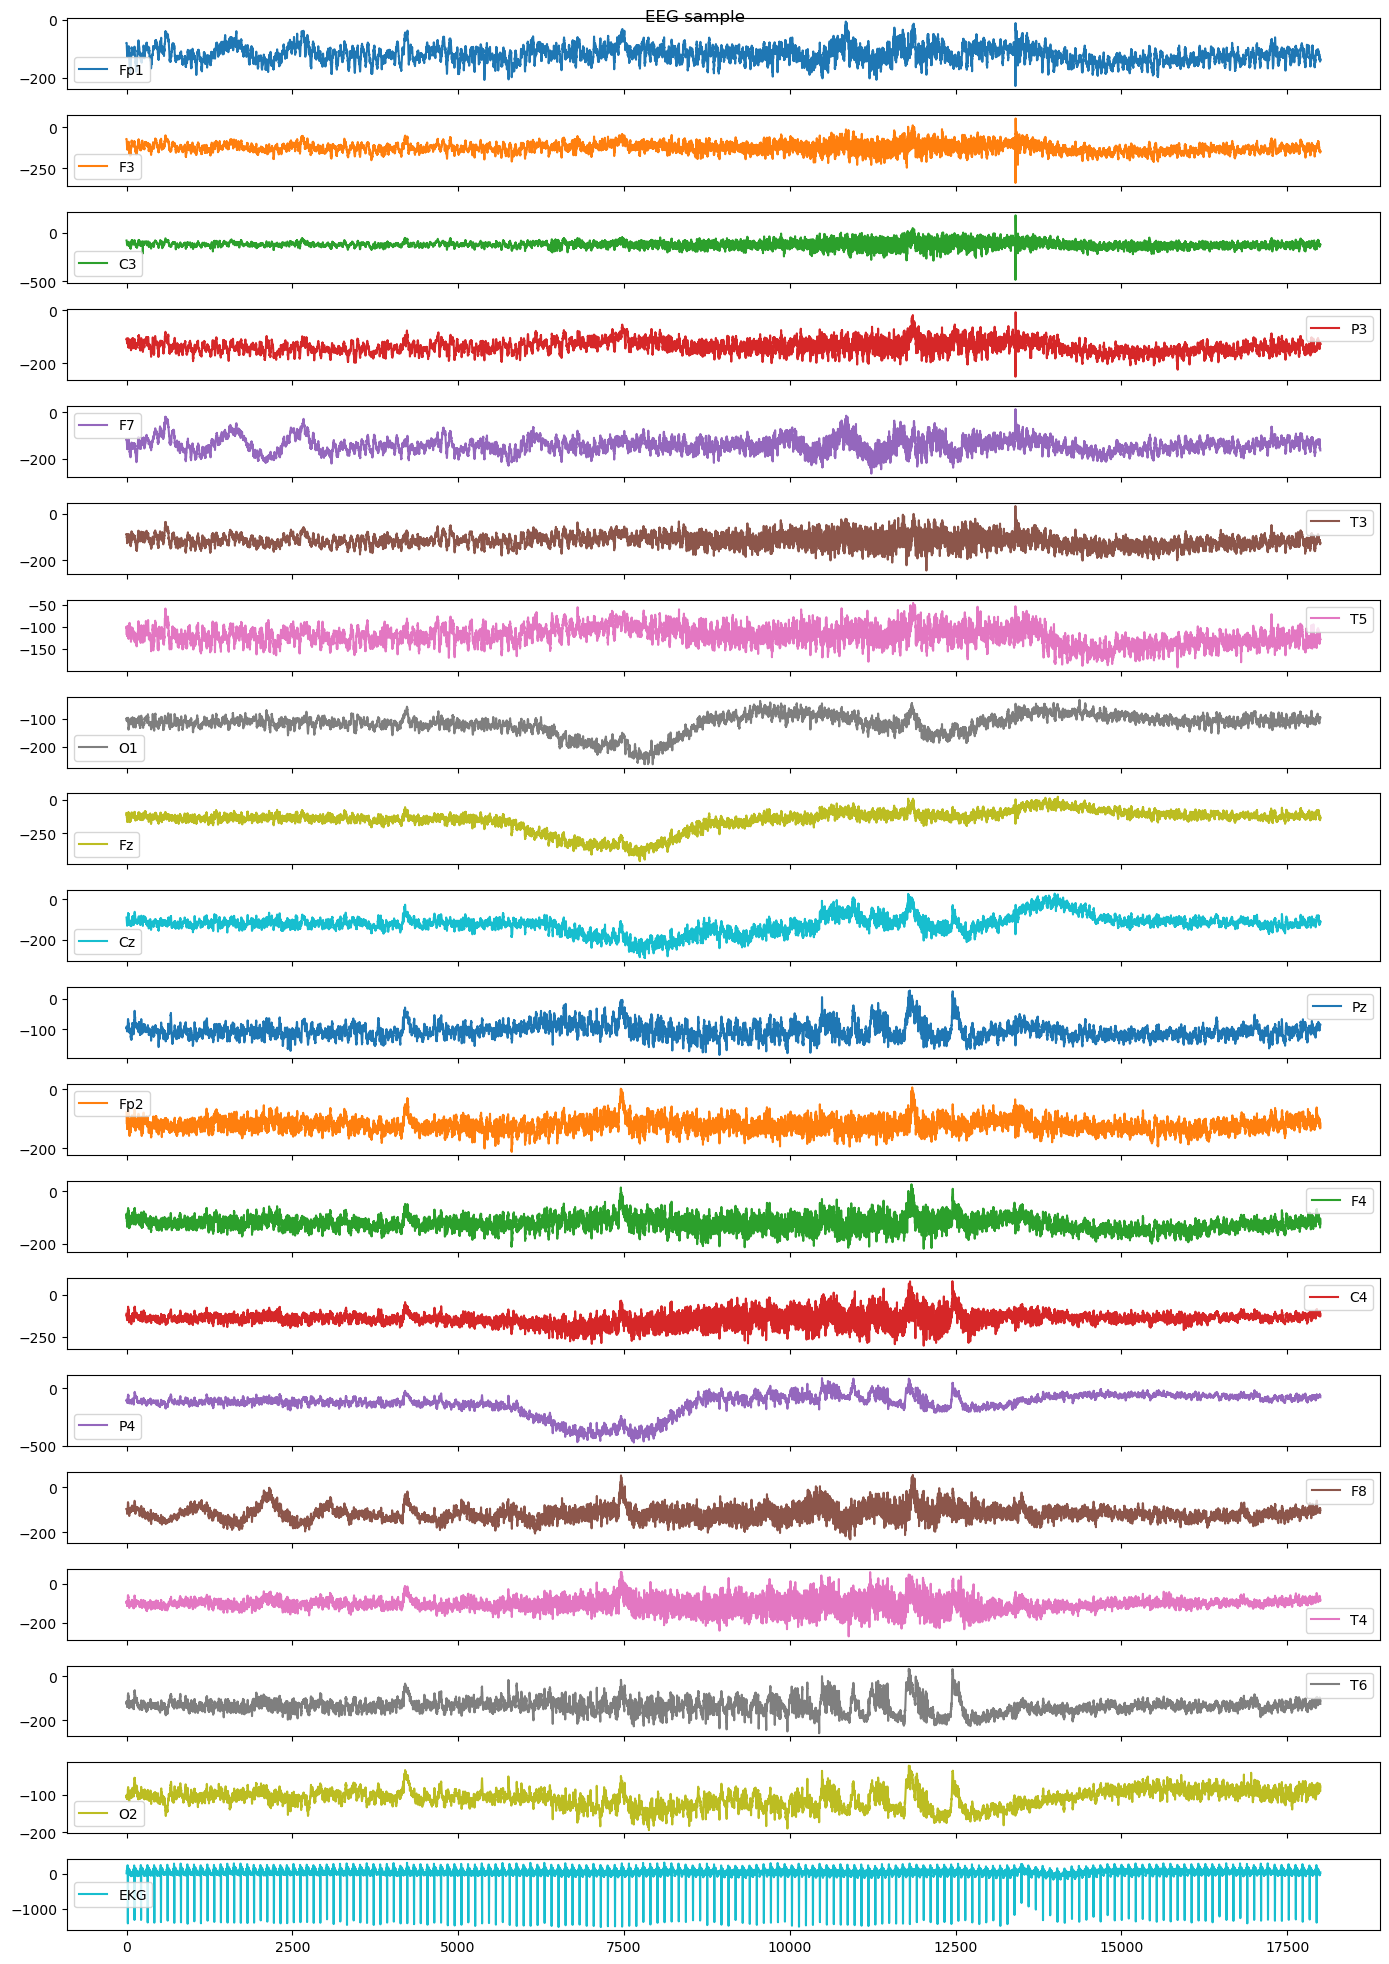

In [2]:
# 하나만 먼저 탐색
sample_id = df['eeg_id'].iloc[0]
eeg = pd.read_parquet(f'/Users/pitzsb1/Documents/train_eegs/{sample_id}.parquet')

print(eeg.shape) # (시간축 길이, 20채널)
print(eeg.columns.tolist())
eeg.plot(subplots=True, figsize=(14, 20), title='EEG sample')
plt.tight_layout()
plt.show()

In [3]:
import pandas as pd

# 하나만 먼저 열기
eeg = pd.read_parquet('/Users/pitzsb1/Documents/train_eegs/1000913311.parquet')

print("Shape:", eeg.shape) # (행 수=시간축, 열 수=채널)
print("\nColumns:", eeg.columns.tolist())
print("\nDtype:\n", eeg.dtypes)
print("\n앞부분:\n", eeg.head())
print("\n기초 통계:\n", eeg.describe())

Shape: (10000, 20)

Columns: ['Fp1', 'F3', 'C3', 'P3', 'F7', 'T3', 'T5', 'O1', 'Fz', 'Cz', 'Pz', 'Fp2', 'F4', 'C4', 'P4', 'F8', 'T4', 'T6', 'O2', 'EKG']

Dtype:
 Fp1    float32
F3     float32
C3     float32
P3     float32
F7     float32
T3     float32
T5     float32
O1     float32
Fz     float32
Cz     float32
Pz     float32
Fp2    float32
F4     float32
C4     float32
P4     float32
F8     float32
T4     float32
T6     float32
O2     float32
EKG    float32
dtype: object

앞부분:
           Fp1          F3         C3         P3          F7          T3  \
0 -105.849998  -89.230003 -79.459999 -49.230000  -99.730003  -87.769997   
1  -85.470001  -75.070000 -60.259998 -38.919998  -73.080002  -87.510002   
2    8.840000   34.849998  56.430000  67.970001   48.099998   25.350000   
3  -56.320000  -37.279999 -28.100000  -2.820000  -43.430000  -35.049999   
4 -110.139999 -104.519997 -96.879997 -70.250000 -111.660004 -114.430000   

          T5         O1         Fz         Cz         Pz        Fp

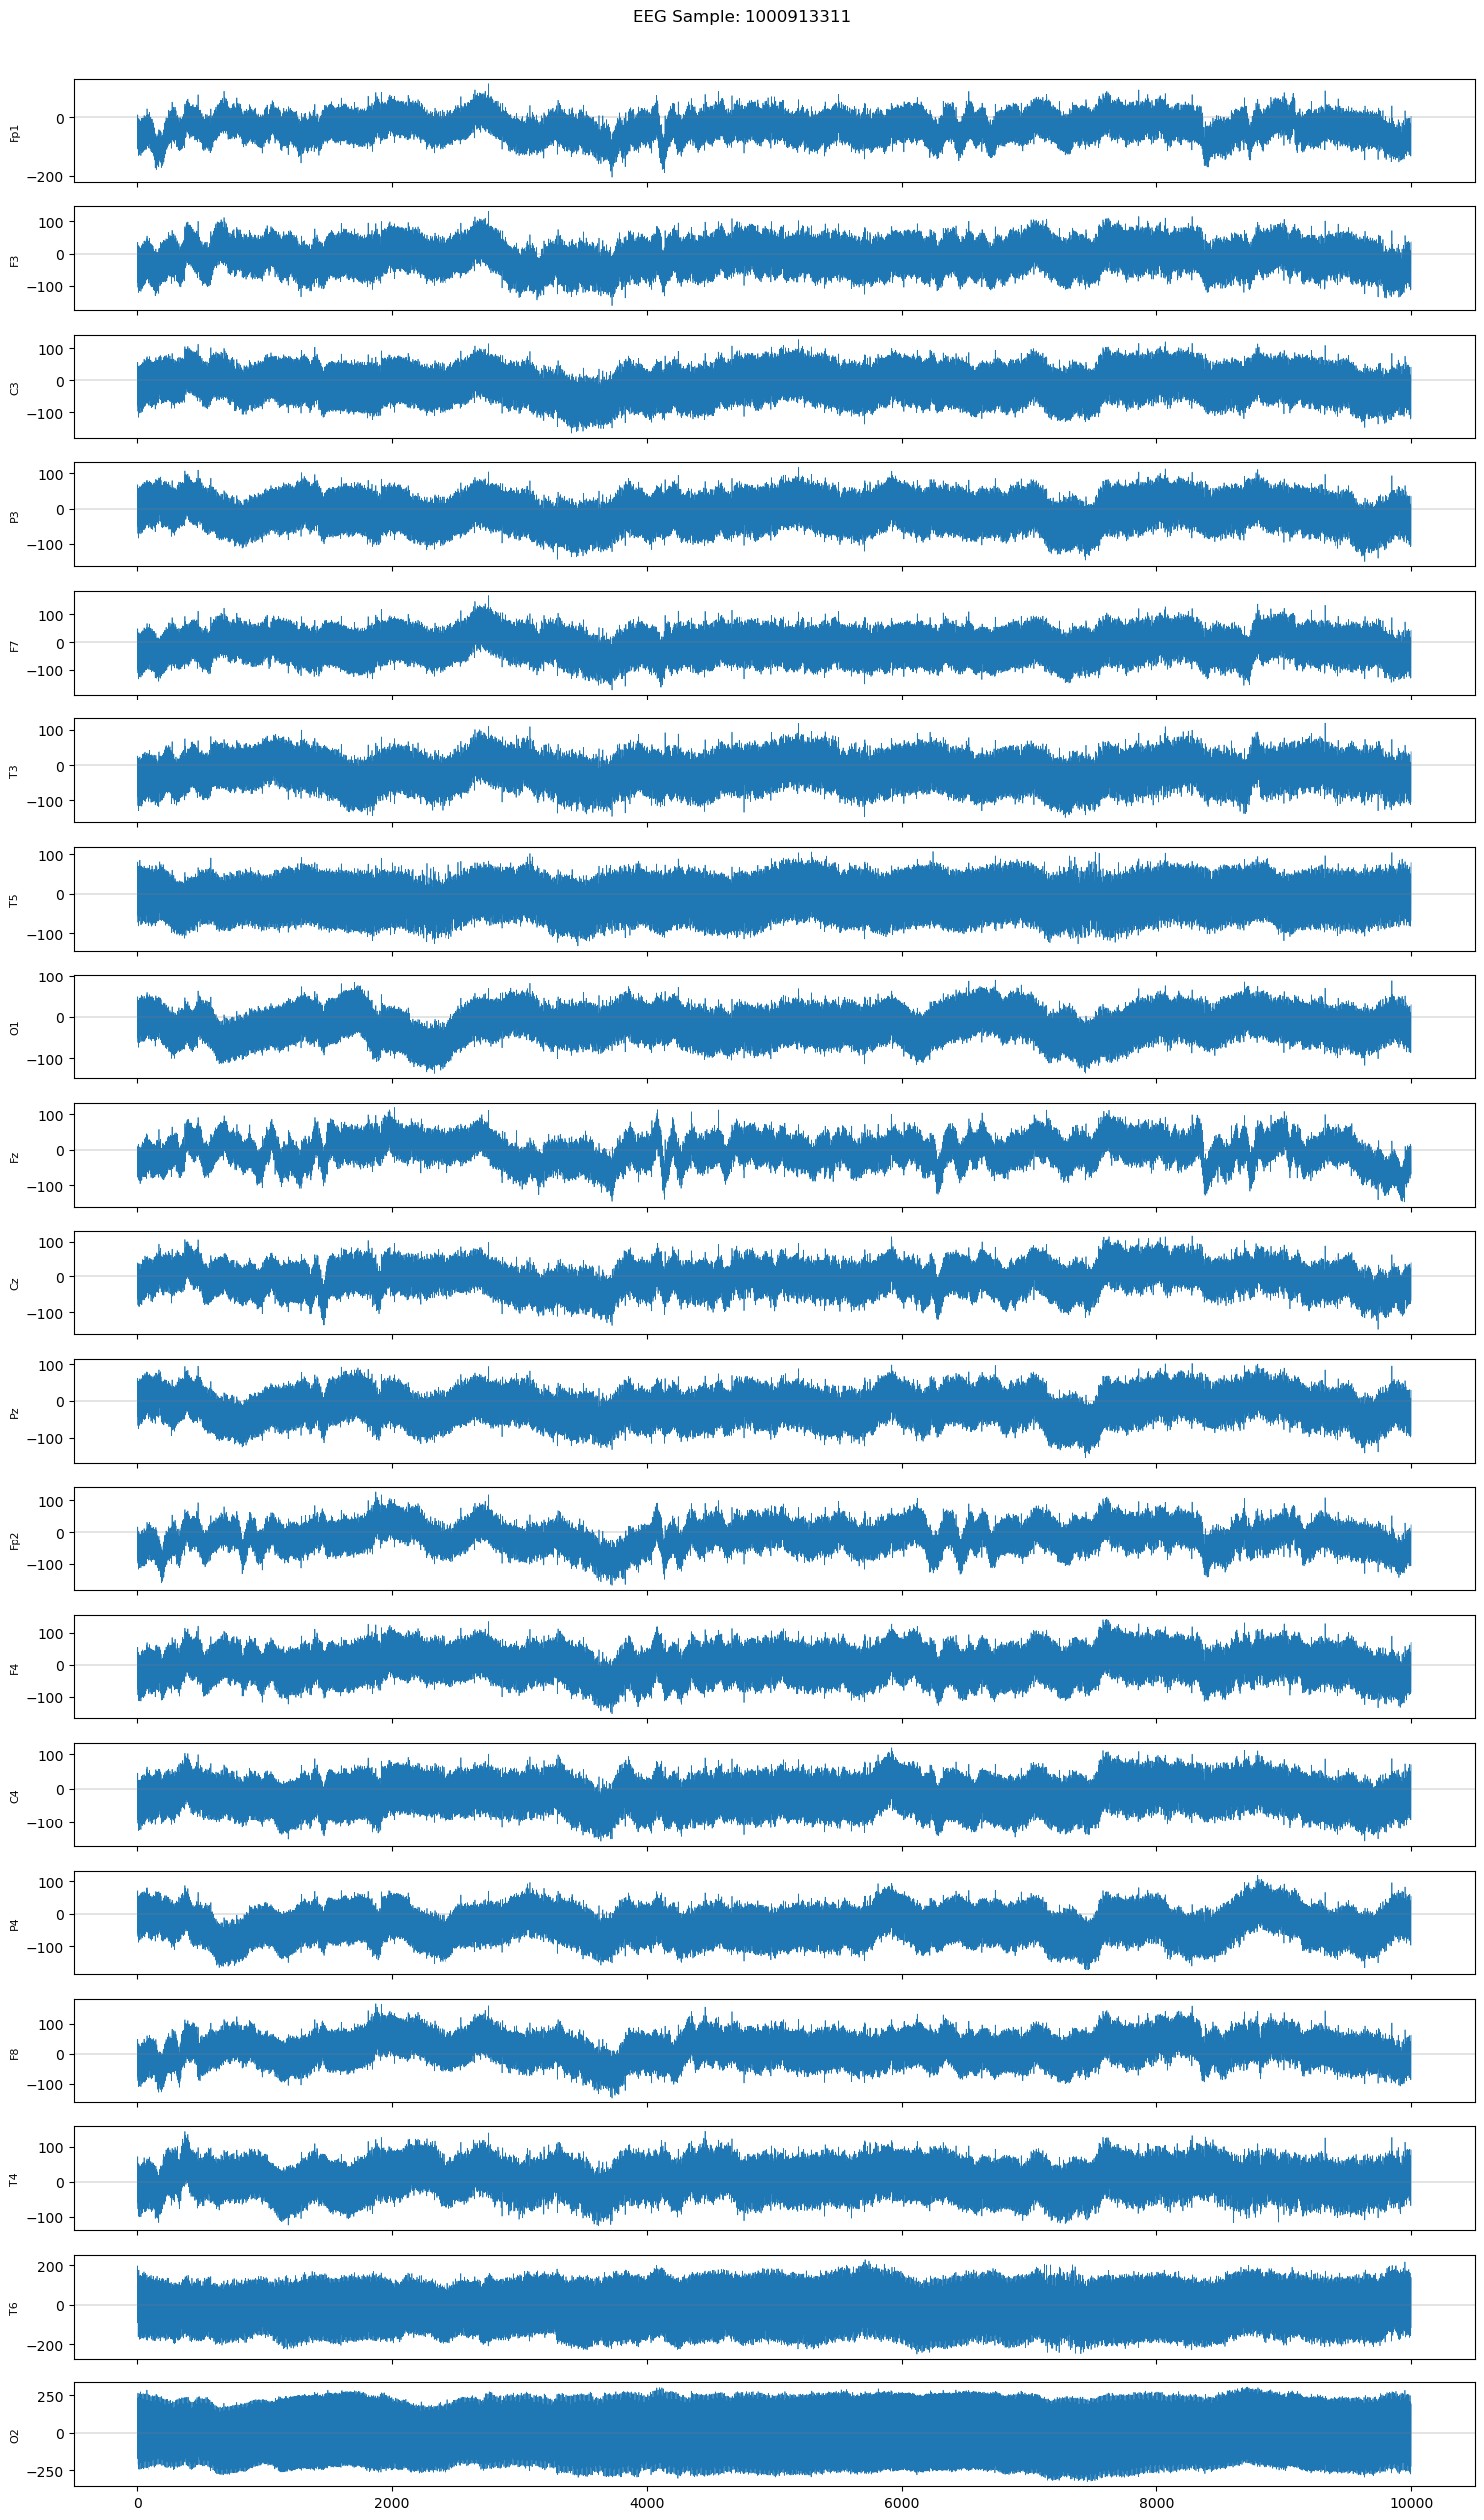

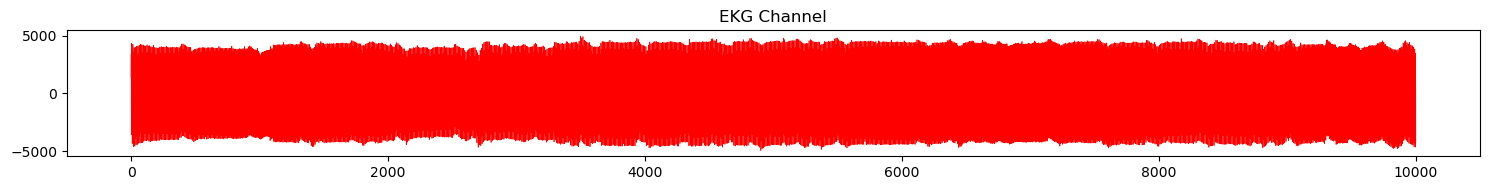

In [4]:
import matplotlib.pyplot as plt

eeg = pd.read_parquet('/Users/pitzsb1/Documents/train_eegs/1000913311.parquet')

# EEG 채널만 (EKG 제외)
eeg_channels = [c for c in eeg.columns if c != 'EKG']

fig, axes = plt.subplots(len(eeg_channels), 1, figsize=(15, 25), sharex=True)

for i, ch in enumerate(eeg_channels):
    axes[i].plot(eeg[ch].values, linewidth=0.5)
    axes[i].set_ylabel(ch, fontsize=8)
    axes[i].axhline(0, color='gray', linewidth=0.3)

plt.suptitle('EEG Sample: 1000913311', y=1.01)
plt.tight_layout()
plt.show()

# EKG 별도 시각화
plt.figure(figsize=(15, 2))
plt.plot(eeg['EKG'].values, linewidth=0.5, color='red')
plt.title('EKG Channel')
plt.tight_layout()
plt.show()

In [5]:
df = pd.read_csv('/Users/pitzsb1/Documents/HBAC/train.csv')
print(df[df['eeg_id'] == 1000913311][['eeg_id', 'expert_consensus', 'seizure_vote', 'lpd_vote', 'gpd_vote', 'lrda_vote', 'grda_vote', 'other_vote']])

          eeg_id expert_consensus  seizure_vote  lpd_vote  gpd_vote  \
9529  1000913311            Other             0         0         0   

      lrda_vote  grda_vote  other_vote  
9529          0          0           2  


In [6]:
import pandas as pd

df = pd.read_csv('/Users/pitzsb1/Documents/HBAC/train.csv')

print("Shape:", df.shape)
print("\n클래스 분포:")
print(df['expert_consensus'].value_counts())
print("\n결측치:")
print(df.isnull().sum())
print("\n앞부분:")
print(df.head())

Shape: (106800, 15)

클래스 분포:
expert_consensus
Seizure    20933
GRDA       18861
Other      18808
GPD        16702
LRDA       16640
LPD        14856
Name: count, dtype: int64

결측치:
eeg_id                              0
eeg_sub_id                          0
eeg_label_offset_seconds            0
spectrogram_id                      0
spectrogram_sub_id                  0
spectrogram_label_offset_seconds    0
label_id                            0
patient_id                          0
expert_consensus                    0
seizure_vote                        0
lpd_vote                            0
gpd_vote                            0
lrda_vote                           0
grda_vote                           0
other_vote                          0
dtype: int64

앞부분:
       eeg_id  eeg_sub_id  eeg_label_offset_seconds  spectrogram_id  \
0  1628180742           0                       0.0          353733   
1  1628180742           1                       6.0          353733   
2  1628180742     

In [7]:
eeg_id = 1000913311
label_info = df[df['eeg_id'] == eeg_id][['eeg_id', 'expert_consensus', 'seizure_vote', 'lpd_vote', 'gpd_vote', 'lrda_vote', 'grda_vote', 'other_vote']]
print(label_info)

          eeg_id expert_consensus  seizure_vote  lpd_vote  gpd_vote  \
9529  1000913311            Other             0         0         0   

      lrda_vote  grda_vote  other_vote  
9529          0          0           2  


In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import os

df = pd.read_csv('/Users/pitzsb1/Documents/HBAC/train.csv')

# 클래스별 대표 eeg_id 하나씩 뽑기
classes = ['Seizure', 'GPD', 'LPD', 'GRDA', 'LRDA', 'Other']
samples = {}
for cls in classes:
    row = df[df['expert_consensus'] == cls].iloc[0]
    samples[cls] = row['eeg_id']

print("클래스별 샘플 eeg_id:")
for cls, eid in samples.items():
    print(f"  {cls}: {eid}")

클래스별 샘플 eeg_id:
  Seizure: 1628180742
  GPD: 2277392603
  LPD: 736446371
  GRDA: 2578018731
  LRDA: 722738444
  Other: 1202099836


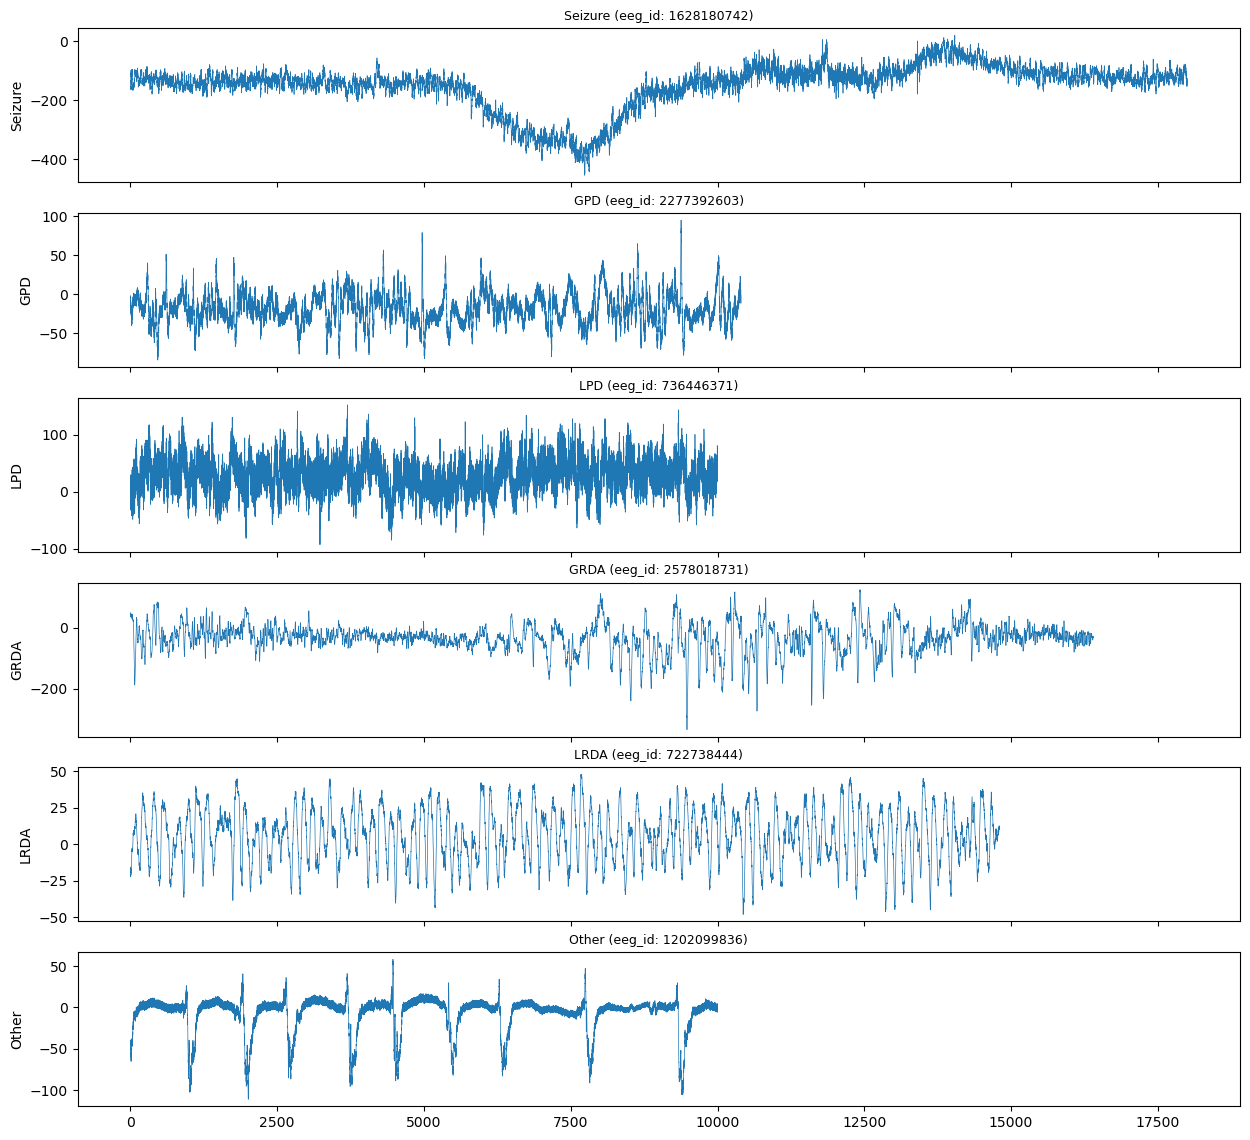

/opt/anaconda3/envs/py311/lib/python3.11/site-packages/IPython/core/events.py:100: UserWarning: Glyph 53364 (\N{HANGUL SYLLABLE KEUL}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/opt/anaconda3/envs/py311/lib/python3.11/site-packages/IPython/core/events.py:100: UserWarning: Glyph 47000 (\N{HANGUL SYLLABLE RAE}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/opt/anaconda3/envs/py311/lib/python3.11/site-packages/IPython/core/events.py:100: UserWarning: Glyph 49828 (\N{HANGUL SYLLABLE SEU}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/opt/anaconda3/envs/py311/lib/python3.11/site-packages/IPython/core/events.py:100: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/opt/anaconda3/envs/py311/lib/python3.11/site-packages/IPython/core/events.py:100: UserWarning: Glyph 49888 (\N{HANGUL SYLLABLE SIN}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/opt/anaconda3/envs/py311/lib/python3

<Figure size 640x480 with 0 Axes>

In [9]:
# 클래스별 신호 비교 시각화 (Fz 채널 하나만)
fig, axes = plt.subplots(6, 1, figsize=(15, 14), sharex=True)

for i, (cls, eid) in enumerate(samples.items()):
    path = f'/Users/pitzsb1/Documents/train_eegs/{eid}.parquet'
    if os.path.exists(path):
        eeg = pd.read_parquet(path)
        axes[i].plot(eeg['Fz'].values, linewidth=0.5)
        axes[i].set_ylabel(cls, fontsize=10)
        axes[i].set_title(f'{cls} (eeg_id: {eid})', fontsize=9)
    else:
        axes[i].text(0.5, 0.5, 'Missing file', ha='center', va='center', fontsize=12, color='red')
        axes[i].set_ylabel(cls, fontsize=10)
        axes[i].set_title(f'{cls} (missing: {eid})', fontsize=9)

plt.show()

plt.suptitle('클래스별 EEG 신호 비교 (Fz 채널)', fontsize=13)
plt.tight_layout()

In [10]:
import os
files = [f for f in os.listdir('/Users/pitzsb1/Documents/train_eegs/') if f.endswith('.parquet')]
print(f"전체 parquet 파일 수: {len(files)}")

# train.csv의 고유 eeg_id 수와 비교
print(f"train.csv 고유 eeg_id 수: {df['eeg_id'].nunique()}")

전체 parquet 파일 수: 17300
train.csv 고유 eeg_id 수: 17089


In [11]:
from sklearn.model_selection import train_test_split

patients = df['patient_id'].unique()

# 환자 기준으로 분할 (train 70 / val 15 / test 15)
train_pts, temp_pts = train_test_split(patients, test_size=0.3, random_state=42)
val_pts, test_pts = train_test_split(temp_pts, test_size=0.5, random_state=42)

train_df = df[df['patient_id'].isin(train_pts)]
val_df   = df[df['patient_id'].isin(val_pts)]
test_df  = df[df['patient_id'].isin(test_pts)]

print(f"Train: {len(train_df)}행 / {train_df['patient_id'].nunique()}명")
print(f"Val:   {len(val_df)}행 / {val_df['patient_id'].nunique()}명")
print(f"Test:  {len(test_df)}행 / {test_df['patient_id'].nunique()}명")

# 클래스 분포 확인 (편향 없는지 체크)
print("\nTrain 클래스 분포:")
print(train_df['expert_consensus'].value_counts(normalize=True).round(3))
print("\nTest 클래스 분포:")
print(test_df['expert_consensus'].value_counts(normalize=True).round(3))

Train: 73731행 / 1365명
Val:   16421행 / 292명
Test:  16648행 / 293명

Train 클래스 분포:
expert_consensus
Seizure    0.195
Other      0.185
GRDA       0.177
LPD        0.159
GPD        0.145
LRDA       0.140
Name: proportion, dtype: float64

Test 클래스 분포:
expert_consensus
Seizure    0.225
LRDA       0.189
Other      0.173
GPD        0.169
GRDA       0.128
LPD        0.117
Name: proportion, dtype: float64
